# Regression

In [317]:
# Versuch Nummer 1; Regression, Vorhersage des audienceScore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

film_daten = pd.read_csv('Dataset/film_level_dataset_reliable.csv')

print(film_daten.head()) #ist korrekt hochgeladen?

                        id  joy_mean  anger_mean  fear_mean  sadness_mean  \
0            009_re_cyborg  0.177228    0.052952   0.107659      0.112802   
1                    1-day  0.134815    0.021872   0.017419      0.090791   
2                       10  0.386193    0.010750   0.051379      0.079324   
3     1000013_12_angry_men  0.246861    0.064991   0.030424      0.041336   
4  10000604-porgy_and_bess  0.328769    0.019606   0.036509      0.081594   

   surprise_mean  disgust_mean  neutral_mean  emotional_intensity_mean  \
0       0.057184      0.226962      0.265214                  0.734786   
1       0.020774      0.162349      0.551980                  0.448020   
2       0.138984      0.158981      0.174390                  0.825610   
3       0.075903      0.050842      0.489642                  0.510358   
4       0.031143      0.058021      0.444357                  0.555643   

   emotional_intensity_std  num_reviews           title  audienceScore  \
0                 

In [218]:
film_daten.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19789 entries, 0 to 19788
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        19789 non-null  object 
 1   joy_mean                  19789 non-null  float64
 2   anger_mean                19789 non-null  float64
 3   fear_mean                 19789 non-null  float64
 4   sadness_mean              19789 non-null  float64
 5   surprise_mean             19789 non-null  float64
 6   disgust_mean              19789 non-null  float64
 7   neutral_mean              19789 non-null  float64
 8   emotional_intensity_mean  19789 non-null  float64
 9   emotional_intensity_std   19789 non-null  float64
 10  num_reviews               19789 non-null  int64  
 11  title                     19789 non-null  object 
 12  audienceScore             19789 non-null  float64
 13  tomatoMeter               19787 non-null  float64
 14  releas

In [219]:
film_daten.isnull().sum()

id                             0
joy_mean                       0
anger_mean                     0
fear_mean                      0
sadness_mean                   0
surprise_mean                  0
disgust_mean                   0
neutral_mean                   0
emotional_intensity_mean       0
emotional_intensity_std        0
num_reviews                    0
title                          0
audienceScore                  0
tomatoMeter                    2
releaseDateStreaming        1364
runtimeMinutes               301
genre                        220
originalLanguage             336
director                      45
writer                      2746
dtype: int64

In [220]:
film_daten['audienceScore'].describe()

count    19789.000000
mean        63.828945
std         20.209227
min          0.000000
25%         49.000000
50%         67.000000
75%         80.000000
max        100.000000
Name: audienceScore, dtype: float64

<Axes: xlabel='audienceScore', ylabel='Count'>

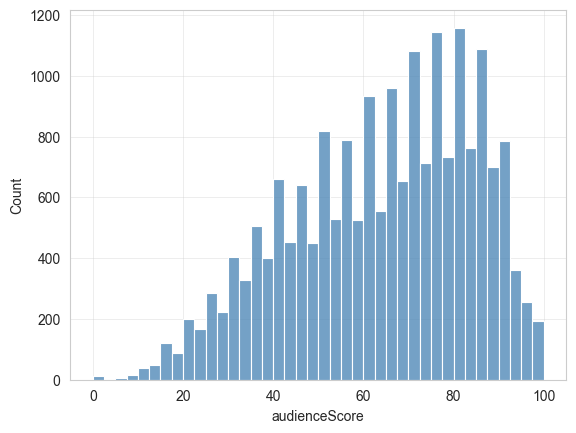

In [221]:
sns.set_style('whitegrid')
sns.histplot(data=film_daten, x='audienceScore', bins=40, color='steelblue') #bins - количество интервалов

<Axes: >

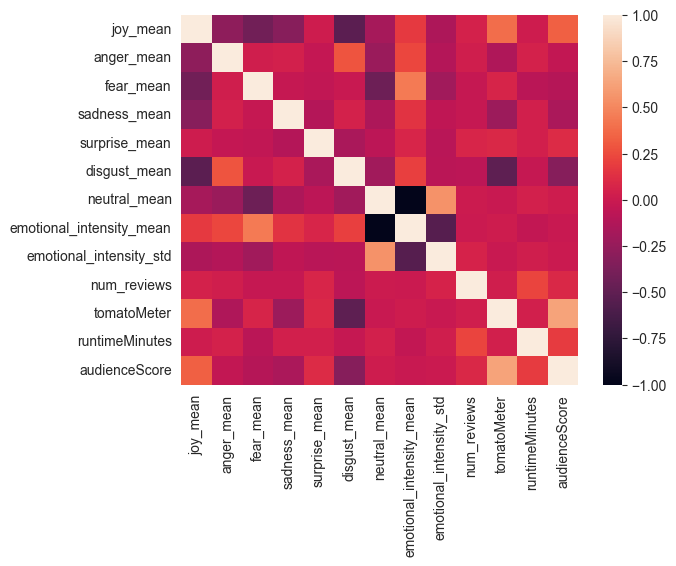

In [222]:
numerische_spalten = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean', 'neutral_mean',
    'emotional_intensity_mean', 'emotional_intensity_std',
    'num_reviews', 'tomatoMeter', 'runtimeMinutes', 'audienceScore'
]

sns.heatmap(film_daten[numerische_spalten].corr()) #die paarweisen Korrelationen aller numerischen Merkmale

In [223]:
# fehlende Werte korrigieren
film_daten['tomatoMeter'] = film_daten['tomatoMeter'].fillna(film_daten['tomatoMeter'].median())
film_daten['runtimeMinutes'] = film_daten['runtimeMinutes'].fillna(film_daten['runtimeMinutes'].median())
print(film_daten.isnull().sum())

id                             0
joy_mean                       0
anger_mean                     0
fear_mean                      0
sadness_mean                   0
surprise_mean                  0
disgust_mean                   0
neutral_mean                   0
emotional_intensity_mean       0
emotional_intensity_std        0
num_reviews                    0
title                          0
audienceScore                  0
tomatoMeter                    0
releaseDateStreaming        1364
runtimeMinutes                 0
genre                        220
originalLanguage             336
director                      45
writer                      2746
dtype: int64


In [224]:
#genre: nur das erste Genre verwenden
film_daten['genre_einfach'] = film_daten['genre'].str.split(',').str[0].str.strip() #новая колонка genre_einfach
film_daten['genre_einfach'] = film_daten['genre_einfach'].fillna('Unbekannt')
film_daten['ist_englisch'] = (film_daten['originalLanguage'].str.contains('English', na=False)).astype(int) #True/False или тоже False, если пусто, тип int

film_daten = pd.get_dummies(film_daten, columns=['genre_einfach']) #pd.get_dummies() ist ne Funktion aus pandas, macht one-hot-encoding

print('Form des Datensatzes nach der Aufbereitung:')
print(film_daten.shape)

Form des Datensatzes nach der Aufbereitung:
(19789, 44)


In [225]:
#test vs. training
from sklearn.model_selection import train_test_split
feature_spalten = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean', 'neutral_mean',
    'emotional_intensity_mean', 'emotional_intensity_std',
    'num_reviews', 'tomatoMeter', 'runtimeMinutes', 'ist_englisch'
] + [col for col in film_daten.columns if col.startswith('genre_einfach_')]

X = film_daten[feature_spalten]
y = film_daten['audienceScore']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=101
)

In [226]:
X_train_skaliert = X_train.copy()
X_test_skaliert = X_test.copy()

print(f'Spalten {X_train_skaliert.columns}')

for column in X_train_skaliert.columns:
    mean_value = X_train_skaliert[column].mean()
    std_value = X_train_skaliert[column].std()

    X_train_skaliert[column] = (X_train_skaliert[column] - mean_value) / std_value
    X_test_skaliert[column] = (X_test_skaliert[column] - mean_value) / std_value

Spalten Index(['joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean', 'surprise_mean',
       'disgust_mean', 'neutral_mean', 'emotional_intensity_mean',
       'emotional_intensity_std', 'num_reviews', 'tomatoMeter',
       'runtimeMinutes', 'ist_englisch', 'genre_einfach_Action',
       'genre_einfach_Adventure', 'genre_einfach_Animation',
       'genre_einfach_Biography', 'genre_einfach_Comedy',
       'genre_einfach_Crime', 'genre_einfach_Documentary',
       'genre_einfach_Drama', 'genre_einfach_Fantasy', 'genre_einfach_History',
       'genre_einfach_Holiday', 'genre_einfach_Horror',
       'genre_einfach_Kids & family', 'genre_einfach_Lgbtq+',
       'genre_einfach_Music', 'genre_einfach_Musical',
       'genre_einfach_Mystery & thriller', 'genre_einfach_Romance',
       'genre_einfach_Sci-fi', 'genre_einfach_Stand-up',
       'genre_einfach_Unbekannt', 'genre_einfach_War',
       'genre_einfach_Western'],
      dtype='object')


In [227]:
X_train_skaliert.runtimeMinutes.mean() #почти 0

np.float64(-2.549354266387069e-16)

In [228]:
X_train_skaliert.runtimeMinutes.std()

np.float64(1.0)

In [229]:
#Modelltraining, modell 1: Lineare Regression
from sklearn import linear_model

clf = linear_model.LinearRegression()
clf.fit(X_train_skaliert, y_train)

LinearRegression()

In [230]:
y_vorhersage_lr = clf.predict(X_test_skaliert)

In [231]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_vorhersage_lr))
mae_lr = mean_absolute_error(y_test, y_vorhersage_lr)
r2_lr = r2_score(y_test, y_vorhersage_lr)

print(f'RMSE: {rmse_lr:.2f}')
print(f'MAE:  {mae_lr:.2f}')
print(f'R²:   {r2_lr:.4f}')

RMSE: 14.68
MAE:  11.66
R²:   0.4724


In [232]:
koeffizienten = pd.DataFrame({
    'Merkmal': feature_spalten,
    'Koeffizient': clf.coef_
})

koeffizienten = koeffizienten.reindex(
    koeffizienten['Koeffizient'].abs().sort_values(ascending=False).index
)
print(koeffizienten.to_string(index=False)) #hier habe ich Multikoliniarität gekriegt

                         Merkmal    Koeffizient
                        joy_mean -198648.445011
                       fear_mean -155167.575868
                    disgust_mean -125765.837540
                    sadness_mean  -86748.172580
        emotional_intensity_mean   77449.037604
                    neutral_mean  -77449.037604
                      anger_mean  -49966.023137
                   surprise_mean  -48656.036852
                     tomatoMeter      10.791509
                  runtimeMinutes       2.992707
       genre_einfach_Documentary       2.160507
            genre_einfach_Horror      -1.808843
                     num_reviews       1.091892
genre_einfach_Mystery & thriller      -1.032860
            genre_einfach_Sci-fi      -0.545700
             genre_einfach_Drama       0.540897
            genre_einfach_Action      -0.538490
            genre_einfach_Comedy      -0.448319
               genre_einfach_War       0.422281
                    ist_englisch      -0

In [233]:
#попытка номер 2...
feature_spalten_korrigiert = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'emotional_intensity_std',
    'num_reviews', 'tomatoMeter', 'runtimeMinutes', 'ist_englisch'
] + [col for col in film_daten.columns if col.startswith('genre_einfach_')]

X_korrigiert = film_daten[feature_spalten_korrigiert]
y_korrigiert = film_daten['audienceScore']

In [234]:
X_train_kor, X_test_kor, y_train_kor, y_test_kor = train_test_split(
    X_korrigiert, y_korrigiert, test_size=0.20, random_state=101
)

In [235]:
X_train_kor_skaliert = X_train_kor.copy()
X_test_kor_skaliert = X_test_kor.copy()

for column in X_train_kor_skaliert.columns:
    mean_value = X_train_kor_skaliert[column].mean()
    std_value = X_train_kor_skaliert[column].std()
    X_train_kor_skaliert[column] = (X_train_kor_skaliert[column] - mean_value) / std_value
    X_test_kor_skaliert[column] = (X_test_kor_skaliert[column] - mean_value) / std_value

In [236]:
clf_kor = linear_model.LinearRegression()
clf_kor.fit(X_train_kor_skaliert, y_train_kor)

LinearRegression()

In [237]:
y_vorhersage_kor = clf_kor.predict(X_test_kor_skaliert)

rmse_kor = np.sqrt(mean_squared_error(y_test_kor, y_vorhersage_kor))
mae_kor = mean_absolute_error(y_test_kor, y_vorhersage_kor)
r2_kor = r2_score(y_test_kor, y_vorhersage_kor)

print(f'RMSE: {rmse_kor:.2f}')
print(f'MAE:  {mae_kor:.2f}')
print(f'R²:   {r2_kor:.4f}')

RMSE: 14.68
MAE:  11.66
R²:   0.4724


In [238]:
koeffizienten_kor = pd.DataFrame({
    'Merkmal': feature_spalten_korrigiert,
    'Koeffizient': clf_kor.coef_
})
koeffizienten_kor = koeffizienten_kor.reindex(
    koeffizienten_kor['Koeffizient'].abs().sort_values(ascending=False).index
)
print(koeffizienten_kor.to_string(index=False)) #уже норм получилось

                         Merkmal  Koeffizient
                     tomatoMeter    10.791589
                  runtimeMinutes     2.992884
                        joy_mean     2.516776
       genre_einfach_Documentary     2.160494
            genre_einfach_Horror    -1.808603
                     num_reviews     1.091696
                      anger_mean     1.064630
genre_einfach_Mystery & thriller    -1.032899
                   surprise_mean     0.580995
            genre_einfach_Sci-fi    -0.545646
             genre_einfach_Drama     0.540575
            genre_einfach_Action    -0.538316
                    disgust_mean     0.529373
            genre_einfach_Comedy    -0.448228
               genre_einfach_War     0.422144
                    ist_englisch    -0.419345
           genre_einfach_History     0.361569
         genre_einfach_Biography     0.355299
           genre_einfach_Fantasy     0.335265
                       fear_mean    -0.329384
           genre_einfach_Musical  

In [239]:
from sklearn.ensemble import RandomForestRegressor #другая здесь не подойдет
wald_modell = RandomForestRegressor(n_estimators=100, random_state=101)
wald_modell.fit(X_train_kor, y_train_kor)

RandomForestRegressor(random_state=101)

In [240]:
y_vorhersage_rf = wald_modell.predict(X_test_kor)

In [241]:
rmse_rf = np.sqrt(mean_squared_error(y_test_kor, y_vorhersage_rf))
mae_rf = mean_absolute_error(y_test_kor, y_vorhersage_rf)
r2_rf = r2_score(y_test_kor, y_vorhersage_rf)

print('Random Forest – Ergebnisse')
print(f'RMSE: {rmse_rf:.2f}')
print(f'MAE:  {mae_rf:.2f}')
print(f'R²:   {r2_rf:.4f}') #ergebnis fast derselbe, muss noch schauen

Random Forest – Ergebnisse
RMSE: 14.84
MAE:  11.75
R²:   0.4606


In [242]:
wichtigkeit = pd.DataFrame({
    'Merkmal': feature_spalten_korrigiert,
    'Wichtigkeit': wald_modell.feature_importances_
}).sort_values('Wichtigkeit', ascending=False)
print(wichtigkeit.head(15).to_string(index=False))

                         Merkmal  Wichtigkeit
                     tomatoMeter     0.427316
                  runtimeMinutes     0.076878
                       fear_mean     0.068254
                        joy_mean     0.060139
                    sadness_mean     0.056649
                   surprise_mean     0.055625
                      anger_mean     0.053646
                    disgust_mean     0.053467
         emotional_intensity_std     0.051282
                     num_reviews     0.043440
       genre_einfach_Documentary     0.008881
             genre_einfach_Drama     0.005636
            genre_einfach_Horror     0.005476
                    ist_englisch     0.004726
genre_einfach_Mystery & thriller     0.004669


Text(0.5, 1.0, 'Merkmalswichtigkeit – Random Forest')

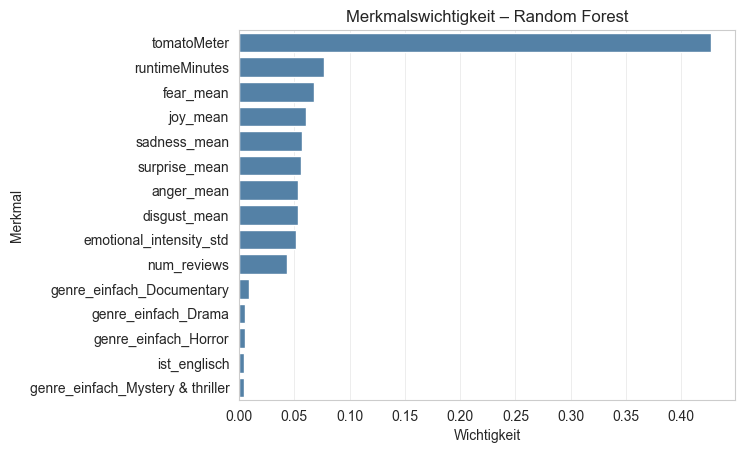

In [243]:
sns.set_style('whitegrid')
sns.barplot(data=wichtigkeit.head(15), x='Wichtigkeit', y='Merkmal', color='steelblue')
plt.title('Merkmalswichtigkeit – Random Forest')

In [244]:
#modell ohne tomato
feature_spalten_ohne_tomato = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'emotional_intensity_std',
    'num_reviews', 'runtimeMinutes', 'ist_englisch'
] + [col for col in film_daten.columns if col.startswith('genre_einfach_')]

X_ohne = film_daten[feature_spalten_ohne_tomato]

In [245]:
X_train_ohne, X_test_ohne, y_train_ohne, y_test_ohne = train_test_split(
    X_ohne, y_korrigiert, test_size=0.20, random_state=101
)

In [246]:
X_train_ohne_skaliert = X_train_ohne.copy()
X_test_ohne_skaliert = X_test_ohne.copy()
for column in X_train_ohne_skaliert.columns:
    mean_value = X_train_ohne_skaliert[column].mean()
    std_value = X_train_ohne_skaliert[column].std()
    X_train_ohne_skaliert[column] = (X_train_ohne_skaliert[column] - mean_value) / std_value
    X_test_ohne_skaliert[column] = (X_test_ohne_skaliert[column] - mean_value) / std_value

In [247]:
clf_ohne = linear_model.LinearRegression()
clf_ohne.fit(X_train_ohne_skaliert, y_train_ohne)

LinearRegression()

In [248]:
y_vorhersage_lr_ohne = clf_ohne.predict(X_test_ohne_skaliert)

rmse_lr_ohne = np.sqrt(mean_squared_error(y_test_ohne, y_vorhersage_lr_ohne))
mae_lr_ohne = mean_absolute_error(y_test_ohne, y_vorhersage_lr_ohne)
r2_lr_ohne = r2_score(y_test_ohne, y_vorhersage_lr_ohne)
print(f'RMSE: {rmse_lr_ohne:.2f}')
print(f'MAE:  {mae_lr_ohne:.2f}')
print(f'R²:   {r2_lr_ohne:.4f}')

RMSE: 16.55
MAE:  13.45
R²:   0.3293


In [249]:
# modell 2 Random Forest ohne tomato
wald_modell_ohne = RandomForestRegressor(n_estimators=100, random_state=101)
wald_modell_ohne.fit(X_train_ohne, y_train_ohne)
y_vorhersage_rf_ohne = wald_modell_ohne.predict(X_test_ohne)

rmse_rf_ohne = np.sqrt(mean_squared_error(y_test_ohne, y_vorhersage_rf_ohne))
mae_rf_ohne = mean_absolute_error(y_test_ohne, y_vorhersage_rf_ohne)
r2_rf_ohne = r2_score(y_test_ohne, y_vorhersage_rf_ohne)
print(f'RMSE: {rmse_rf_ohne:.2f}')
print(f'MAE:  {mae_rf_ohne:.2f}')
print(f'R²:   {r2_rf_ohne:.4f}') #aus meiner Sicht, das ist unzureichend...

RMSE: 16.29
MAE:  13.10
R²:   0.3502


In [250]:
#vergleich aller 4 Modelle
vergleich = pd.DataFrame({
    'Modell': ['Lineare Regression (mit tomatoMeter)',
               'Random Forest (mit tomatoMeter)',
               'Lineare Regression (ohne tomatoMeter)',
               'Random Forest (ohne tomatoMeter)'],
    'RMSE': [rmse_lr, rmse_rf, rmse_lr_ohne, rmse_rf_ohne],
    'MAE':  [mae_lr, mae_rf, mae_lr_ohne, mae_rf_ohne],
    'R²':   [r2_lr, r2_rf, r2_lr_ohne, r2_rf_ohne]
})
print(vergleich.to_string(index=False))

                               Modell      RMSE       MAE       R²
 Lineare Regression (mit tomatoMeter) 14.680822 11.660896 0.472413
      Random Forest (mit tomatoMeter) 14.844276 11.752360 0.460600
Lineare Regression (ohne tomatoMeter) 16.553113 13.450911 0.329263
     Random Forest (ohne tomatoMeter) 16.292237 13.099404 0.350238


In [251]:
#versuche was anderes zu untersuchen
film_daten['meinungsverschiedenheit'] = film_daten['audienceScore'] - film_daten['tomatoMeter']
print(film_daten['meinungsverschiedenheit'].describe())

count    19789.000000
mean        -2.383445
std         21.188490
min        -88.000000
25%        -16.000000
50%         -4.000000
75%         10.000000
max         92.000000
Name: meinungsverschiedenheit, dtype: float64


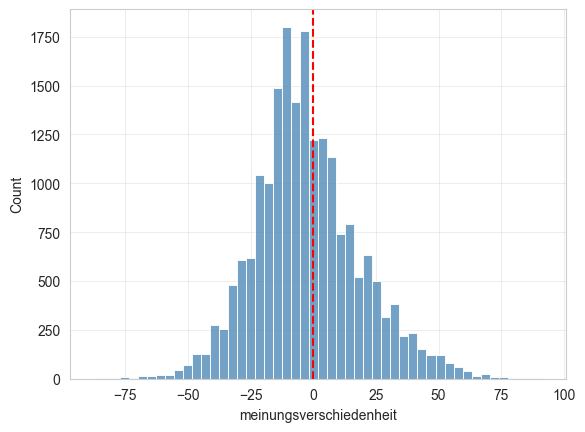

In [252]:
# Verteilung visualisieren
sns.set_style('whitegrid')
sns.histplot(data=film_daten, x='meinungsverschiedenheit', bins=50, color='steelblue')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--')

## Попытка новой регрессии

In [253]:
#modelle mir neuer Zielvariable
y_neu = film_daten['meinungsverschiedenheit']

# Features ohne tomatoMeter (steckt schon in der Zielvariable) und
# ohne die multikollinearen Merkmale
feature_spalten_neu = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'emotional_intensity_std',
    'num_reviews', 'runtimeMinutes', 'ist_englisch'
] + [col for col in film_daten.columns if col.startswith('genre_einfach_')]

X_neu = film_daten[feature_spalten_neu]

In [254]:
#test vs. trainings
X_train_neu, X_test_neu, y_train_neu, y_test_neu = train_test_split(
    X_neu, y_neu, test_size=0.20, random_state=101
)

In [255]:
X_train_neu_skaliert = X_train_neu.copy()
X_test_neu_skaliert = X_test_neu.copy()

for column in X_train_neu_skaliert.columns:
    mean_value = X_train_neu_skaliert[column].mean()
    std_value = X_train_neu_skaliert[column].std()
    X_train_neu_skaliert[column] = (X_train_neu_skaliert[column] - mean_value) / std_value
    X_test_neu_skaliert[column] = (X_test_neu_skaliert[column] - mean_value) / std_value

In [256]:
#Modell 1, Lineare Regression mit neuer Variable
clf_neu = linear_model.LinearRegression()
clf_neu.fit(X_train_neu_skaliert, y_train_neu)
y_vorhersage_lr_neu = clf_neu.predict(X_test_neu_skaliert)

rmse_lr_neu = np.sqrt(mean_squared_error(y_test_neu, y_vorhersage_lr_neu))
mae_lr_neu = mean_absolute_error(y_test_neu, y_vorhersage_lr_neu)
r2_lr_neu = r2_score(y_test_neu, y_vorhersage_lr_neu)
print(f'RMSE: {rmse_lr_neu:.2f}')
print(f'MAE:  {mae_lr_neu:.2f}')
print(f'R²:   {r2_lr_neu:.4f}') #omg, that's bad

RMSE: 18.76
MAE:  14.42
R²:   0.2162


In [257]:
#modell 2, random forest mit Meinungsverschiedenheit
wald_modell_neu = RandomForestRegressor(n_estimators=100, random_state=101)
wald_modell_neu.fit(X_train_neu, y_train_neu)
y_vorhersage_rf_neu = wald_modell_neu.predict(X_test_neu)

rmse_rf_neu = np.sqrt(mean_squared_error(y_test_neu, y_vorhersage_rf_neu))
mae_rf_neu = mean_absolute_error(y_test_neu, y_vorhersage_rf_neu)
r2_rf_neu = r2_score(y_test_neu, y_vorhersage_rf_neu)

print(f'RMSE: {rmse_rf_neu:.2f}')
print(f'MAE:  {mae_rf_neu:.2f}')
print(f'R²:   {r2_rf_neu:.4f}')

RMSE: 18.35
MAE:  14.03
R²:   0.2498


In [258]:
#schauen mal wichtigkeit
wichtigkeit_neu = pd.DataFrame({
    'Merkmal': feature_spalten_neu,
    'Wichtigkeit': wald_modell_neu.feature_importances_
}).sort_values('Wichtigkeit', ascending=False)
print(wichtigkeit_neu.head(12).to_string(index=False))

                  Merkmal  Wichtigkeit
             disgust_mean     0.186383
                fear_mean     0.130487
                 joy_mean     0.105612
             sadness_mean     0.086502
           runtimeMinutes     0.086097
               anger_mean     0.082250
            surprise_mean     0.079706
  emotional_intensity_std     0.079588
              num_reviews     0.064575
             ist_englisch     0.019140
genre_einfach_Documentary     0.018702
      genre_einfach_Drama     0.009354


<Axes: xlabel='Wichtigkeit', ylabel='Merkmal'>

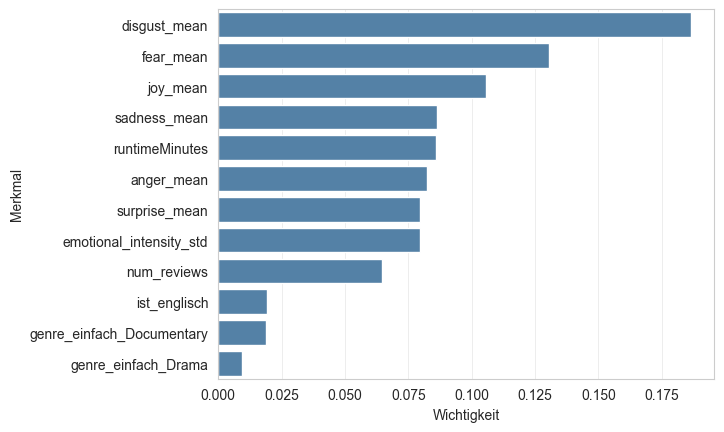

In [259]:
sns.set_style('whitegrid')
sns.barplot(data=wichtigkeit_neu.head(12), x='Wichtigkeit', y='Merkmal', color='steelblue')

## новые признаки

In [292]:
merged = pd.read_csv('Dataset/merged_clean.csv')


In [294]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318419 entries, 0 to 1318418
Data columns (total 29 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1318419 non-null  object 
 1   reviewId              1318419 non-null  int64  
 2   creationDate          1318419 non-null  object 
 3   criticName            1318419 non-null  object 
 4   isTopCritic           1318419 non-null  bool   
 5   originalScore         899408 non-null   object 
 6   reviewState           1318419 non-null  object 
 7   publicatioName        1318419 non-null  object 
 8   reviewText            1318419 non-null  object 
 9   scoreSentiment        1318419 non-null  object 
 10  reviewUrl             1167126 non-null  object 
 11  word_count            1318419 non-null  int64  
 12  language              1318419 non-null  object 
 13  letter_ratio          1318419 non-null  float64
 14  title                 1318419 non-

In [ ]:
merged.hist()

In [260]:
#neue Merkmale aus merged_clean können vielleicht relevant sein
merged = pd.read_csv('Dataset/merged_clean.csv')
neue_merkmale = merged.groupby('id').agg(
    anteil_positive=('scoreSentiment', lambda x: (x == 'POSITIVE').mean()),
    anteil_top_kritiker=('isTopCritic', 'mean'),
    durchschnitt_wortanzahl=('word_count', 'mean')
).reset_index()

print(neue_merkmale.head())
print(neue_merkmale.describe())

              id  anteil_positive  anteil_top_kritiker  \
0       $5_a_day         0.333333             0.000000   
1  009_re_cyborg         0.230769             0.307692   
2         00_mhz         0.666667             0.000000   
3              1         1.000000             0.000000   
4          1-day         0.533333             0.666667   

   durchschnitt_wortanzahl  
0                22.666667  
1                19.076923  
2                21.666667  
3                14.000000  
4                23.466667  
       anteil_positive  anteil_top_kritiker  durchschnitt_wortanzahl
count     66333.000000         66333.000000             66333.000000
mean          0.653197             0.265133                21.223506
std           0.367515             0.292623                 6.492738
min           0.000000             0.000000                 5.000000
25%           0.388889             0.000000                17.750000
50%           0.777778             0.222222                21.5

In [261]:
#соединяем
film_daten_erweitert = film_daten.merge(neue_merkmale, on='id', how='left')

print(f'Datensatz vor Zusammenfuehrung: {film_daten.shape}')
print(f'Datensatz nach Zusammenfuehrung: {film_daten_erweitert.shape}')
print('Fehlende Werte in neuen Merkmalen:')
print(film_daten_erweitert[['anteil_positive', 'anteil_top_kritiker', 'durchschnitt_wortanzahl']].isnull().sum())

Datensatz vor Zusammenfuehrung: (19789, 45)
Datensatz nach Zusammenfuehrung: (19789, 48)
Fehlende Werte in neuen Merkmalen:
anteil_positive            0
anteil_top_kritiker        0
durchschnitt_wortanzahl    0
dtype: int64


In [262]:
film_daten_erweitert['anteil_positive'] = film_daten_erweitert['anteil_positive'].fillna(film_daten_erweitert['anteil_positive'].median())
film_daten_erweitert['anteil_top_kritiker'] = film_daten_erweitert['anteil_top_kritiker'].fillna(film_daten_erweitert['anteil_top_kritiker'].median())
film_daten_erweitert['durchschnitt_wortanzahl'] = film_daten_erweitert['durchschnitt_wortanzahl'].fillna(film_daten_erweitert['durchschnitt_wortanzahl'].median())

In [263]:
#modell mit weiteren daten trainieren
feature_spalten_erweitert = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'emotional_intensity_std',
    'num_reviews', 'runtimeMinutes', 'ist_englisch',
    'anteil_positive', 'anteil_top_kritiker', 'durchschnitt_wortanzahl'
] + [col for col in film_daten_erweitert.columns if col.startswith('genre_einfach_')]

X_erweitert = film_daten_erweitert[feature_spalten_erweitert]
y_erweitert = film_daten_erweitert['audienceScore']

In [264]:
#Train-Test-Split
X_train_erw, X_test_erw, y_train_erw, y_test_erw = train_test_split(
    X_erweitert, y_erweitert, test_size=0.20, random_state=101
)

In [265]:
#Skalierung
X_train_erw_skaliert = X_train_erw.copy()
X_test_erw_skaliert = X_test_erw.copy()

for column in X_train_erw_skaliert.columns:
    mean_value = X_train_erw_skaliert[column].mean()
    std_value = X_train_erw_skaliert[column].std()
    X_train_erw_skaliert[column] = (X_train_erw_skaliert[column] - mean_value) / std_value
    X_test_erw_skaliert[column] = (X_test_erw_skaliert[column] - mean_value) / std_value

In [266]:
#wieder Modell 1, Lineare Regression
clf_erw = linear_model.LinearRegression()
clf_erw.fit(X_train_erw_skaliert, y_train_erw)
y_vorhersage_lr_erw = clf_erw.predict(X_test_erw_skaliert)

rmse_lr_erw = np.sqrt(mean_squared_error(y_test_erw, y_vorhersage_lr_erw))
mae_lr_erw = mean_absolute_error(y_test_erw, y_vorhersage_lr_erw)
r2_lr_erw = r2_score(y_test_erw, y_vorhersage_lr_erw)
print(f'RMSE: {rmse_lr_erw:.2f}')
print(f'MAE:  {mae_lr_erw:.2f}')
print(f'R²:   {r2_lr_erw:.4f}') #ich galube, dass anteil_positive fast dasselbe macht, was tomatoMeter

RMSE: 14.69
MAE:  11.66
R²:   0.4716


In [267]:
#modell 2 random forest
wald_modell_erw = RandomForestRegressor(n_estimators=100, random_state=101)
wald_modell_erw.fit(X_train_erw, y_train_erw)
y_vorhersage_rf_erw = wald_modell_erw.predict(X_test_erw)
rmse_rf_erw = np.sqrt(mean_squared_error(y_test_erw, y_vorhersage_rf_erw))
mae_rf_erw = mean_absolute_error(y_test_erw, y_vorhersage_rf_erw)
r2_rf_erw = r2_score(y_test_erw, y_vorhersage_rf_erw)
print(f'RMSE: {rmse_rf_erw:.2f}')
print(f'MAE:  {mae_rf_erw:.2f}')
print(f'R²:   {r2_rf_erw:.4f}') #kein Unterschied

RMSE: 14.75
MAE:  11.61
R²:   0.4676


## Neue Logik - Reviews und Emotionen sind von Kritiken!!!

In [268]:
zusatz_merkmale = merged[['id', 'rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].drop_duplicates(subset='id')

print(f'Filme mit zusaetzlichen Merkmalen: {zusatz_merkmale.shape[0]}')
print(zusatz_merkmale.head())

Filme mit zusaetzlichen Merkmalen: 66333
                                   id rating ratingContents boxOffice  \
0                             beavers    NaN            NaN       NaN   
1                          blood_mask    NaN            NaN       NaN   
2   city_hunter_shinjuku_private_eyes    NaN            NaN       NaN   
4                  dangerous_men_2015    NaN            NaN       NaN   
14               small_town_wisconsin    NaN            NaN       NaN   

   releaseDateTheaters  
0                  NaN  
1                  NaN  
2                  NaN  
4                  NaN  
14          2022-06-03  


In [269]:
film_daten = film_daten.merge(zusatz_merkmale, on='id', how='left')
print(f'Datensatz nach Zusammenfuehrung: {film_daten.shape}')
print('Fehlende Werte in den neuen Merkmalen:')
print(film_daten[['rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].isnull().sum())

Datensatz nach Zusammenfuehrung: (19789, 49)
Fehlende Werte in den neuen Merkmalen:
rating                 11819
ratingContents         11819
boxOffice               8926
releaseDateTheaters     5397
dtype: int64


In [270]:
film_daten['rating'] = film_daten['rating'].fillna('Unbekannt')
print('Fehlende Werte nach der Bereinigung:')
print(film_daten[['rating', 'ratingContents', 'boxOffice', 'releaseDateTheaters']].isnull().sum())

Fehlende Werte nach der Bereinigung:
rating                     0
ratingContents         11819
boxOffice               8926
releaseDateTheaters     5397
dtype: int64


In [271]:
def parse_box_office(wert):
    if pd.isna(wert):
        return np.nan
    wert = wert.replace('$', '').strip()
    if wert.endswith('K'):
        return float(wert[:-1]) * 1_000
    elif wert.endswith('M'):
        return float(wert[:-1]) * 1_000_000
    elif wert.endswith('B'):
        return float(wert[:-1]) * 1_000_000_000
    else:
        return float(wert)

film_daten['boxOffice_num'] = film_daten['boxOffice'].apply(parse_box_office)
print(film_daten[['boxOffice', 'boxOffice_num']].head(10))

  boxOffice  boxOffice_num
0       NaN            NaN
1       NaN            NaN
2       NaN            NaN
3       NaN            NaN
4       NaN            NaN
5       NaN            NaN
6       NaN            NaN
7    $94.8M     94800000.0
8       NaN            NaN
9       NaN            NaN


In [272]:
film_daten['releaseYear_theaters'] = pd.to_datetime(
    film_daten['releaseDateTheaters'], errors='coerce'
).dt.year
print(film_daten[['releaseDateTheaters', 'releaseYear_theaters']].head(10))

  releaseDateTheaters  releaseYear_theaters
0                 NaN                   NaN
1                 NaN                   NaN
2          1979-10-05                1979.0
3          1957-04-20                1957.0
4          1959-06-24                1959.0
5          1927-08-20                1927.0
6          1954-12-23                1954.0
7          2008-03-07                2008.0
8          2015-07-10                2015.0
9          1935-06-18                1935.0


In [273]:
film_daten['releaseMonth_theaters'] = pd.to_datetime(
    film_daten['releaseDateTheaters'], errors='coerce'
).dt.month
print(film_daten[['releaseDateTheaters', 'releaseMonth_theaters']].head(10))

  releaseDateTheaters  releaseMonth_theaters
0                 NaN                    NaN
1                 NaN                    NaN
2          1979-10-05                   10.0
3          1957-04-20                    4.0
4          1959-06-24                    6.0
5          1927-08-20                    8.0
6          1954-12-23                   12.0
7          2008-03-07                    3.0
8          2015-07-10                    7.0
9          1935-06-18                    6.0


In [274]:
def zaehle_rating_gruende(text):
    if pd.isna(text):
        return 0
    gruende = text.split(',')
    return len(gruende)

film_daten['ratingContents_anzahl'] = film_daten['ratingContents'].apply(zaehle_rating_gruende)
print(film_daten[['ratingContents', 'ratingContents_anzahl']].head(10))

                                      ratingContents  ratingContents_anzahl
0                                                NaN                      0
1                                                NaN                      0
2                                                NaN                      0
3                                                NaN                      0
4                                                NaN                      0
5                                                NaN                      0
6                                                NaN                      0
7        ['Violence', 'Sequences of Intense Action']                      2
8  ['Some Strong Sexual Content', 'Brief Graphic ...                      4
9                                                NaN                      0


In [275]:
print(film_daten['ratingContents'].iloc[8])

['Some Strong Sexual Content', 'Brief Graphic Nudity', 'Language', 'Dialogue']


In [277]:
#mache dieses Mal lieber Multi-Genre
genre_dummies_multi = film_daten['genre'].fillna('').str.get_dummies(sep=', ')
genre_dummies_multi = genre_dummies_multi.add_prefix('genre_multi_')
print(f'Anzahl Multi-Genre-Spalten: {genre_dummies_multi.shape[1]}')
print(genre_dummies_multi.head())

Anzahl Multi-Genre-Spalten: 28
   genre_multi_Action  genre_multi_Adventure  genre_multi_Animation  \
0                   1                      0                      1   
1                   0                      0                      0   
2                   0                      0                      0   
3                   0                      0                      0   
4                   0                      0                      0   

   genre_multi_Anime  genre_multi_Biography  genre_multi_Comedy  \
0                  0                      0                   0   
1                  0                      0                   0   
2                  0                      0                   1   
3                  0                      0                   0   
4                  0                      0                   0   

   genre_multi_Crime  genre_multi_Documentary  genre_multi_Drama  \
0                  0                        0                  0   
1  

In [278]:
film_daten = pd.concat([film_daten, genre_dummies_multi], axis=1)
film_daten['genre_count'] = film_daten['genre'].fillna('').apply(
    lambda x: len([g.strip() for g in x.split(',') if g.strip() != ''])
)
print(f'Form des Datensatzes: {film_daten.shape}')
print(film_daten[['title', 'genre', 'genre_count']].head())

Form des Datensatzes: (19789, 82)
            title                      genre  genre_count
0  009 Re: Cyborg  Action, Sci-fi, Animation            3
1           1 Day                      Drama            1
2              10            Romance, Comedy            2
3    12 Angry Men                      Drama            1
4  Porgy and Bess    Drama, Musical, Romance            3


In [279]:
rating_dummies = pd.get_dummies(film_daten['rating'], prefix='rating')
film_daten = pd.concat([film_daten, rating_dummies], axis=1)
print(f'Anzahl rating-Spalten: {rating_dummies.shape[1]}')
print(rating_dummies.columns.tolist())

Anzahl rating-Spalten: 9
['rating_NC-17', 'rating_PG', 'rating_PG-13', 'rating_R', 'rating_TV14', 'rating_TVMA', 'rating_TVPG', 'rating_TVY7', 'rating_Unbekannt']


In [280]:
genre_multi_spalten = [col for col in film_daten.columns if col.startswith('genre_multi_')]
rating_spalten = [col for col in film_daten.columns if col.startswith('rating_')]
feature_spalten_tomato = [
    'joy_mean', 'anger_mean', 'fear_mean', 'sadness_mean',
    'surprise_mean', 'disgust_mean',
    'emotional_intensity_std',
    'num_reviews', 'runtimeMinutes', 'ist_englisch',
    'genre_count', 'releaseYear_theaters', 'releaseMonth_theaters',
    'boxOffice_num', 'ratingContents_anzahl'
] + genre_multi_spalten + rating_spalten

X_tomato = film_daten[feature_spalten_tomato]
y_tomato = film_daten['tomatoMeter']
print(f'Anzahl Features: {len(feature_spalten_tomato)}')
print(f'Anzahl Datenpunkte (vor Bereinigung): {X_tomato.shape[0]}')

Anzahl Features: 52
Anzahl Datenpunkte (vor Bereinigung): 19789


In [281]:
for spalte in ['boxOffice_num', 'releaseYear_theaters', 'releaseMonth_theaters', 'ratingContents_anzahl']:
    film_daten[spalte] = film_daten[spalte].fillna(film_daten[spalte].median())
X_tomato = film_daten[feature_spalten_tomato]
print('Fehlende Werte nach der Bereinigung:')
print(X_tomato.isnull().sum().sum())

Fehlende Werte nach der Bereinigung:
0


In [282]:
#train vs test
X_train_tomato, X_test_tomato, y_train_tomato, y_test_tomato = train_test_split(
    X_tomato, y_tomato, test_size=0.20, random_state=101
)
print(f'Trainingsdaten: {X_train_tomato.shape[0]} Filme')
print(f'Testdaten: {X_test_tomato.shape[0]} Filme')

Trainingsdaten: 15831 Filme
Testdaten: 3958 Filme


In [283]:
X_train_tomato_skaliert = X_train_tomato.copy()
X_test_tomato_skaliert = X_test_tomato.copy()

for column in X_train_tomato_skaliert.columns:
    mean_value = X_train_tomato_skaliert[column].mean()
    std_value = X_train_tomato_skaliert[column].std()
    X_train_tomato_skaliert[column] = (X_train_tomato_skaliert[column] - mean_value) / std_value
    X_test_tomato_skaliert[column] = (X_test_tomato_skaliert[column] - mean_value) / std_value

In [318]:
#modell 1, lr
clf_tomato = linear_model.LinearRegression()
clf_tomato.fit(X_train_tomato_skaliert, y_train_tomato)
y_vorhersage_lr_tomato = clf_tomato.predict(X_test_tomato_skaliert)

rmse_lr_tomato = np.sqrt(mean_squared_error(y_test_tomato, y_vorhersage_lr_tomato))
mae_lr_tomato = mean_absolute_error(y_test_tomato, y_vorhersage_lr_tomato)
r2_lr_tomato = r2_score(y_test_tomato, y_vorhersage_lr_tomato)
print(f'RMSE: {rmse_lr_tomato:.2f}')
print(f'MAE:  {mae_lr_tomato:.2f}')
print(f'R²:   {r2_lr_tomato:.4f}')

RMSE: 17.93
MAE:  14.28
R²:   0.5573


In [315]:
#modell 2, rf
wald_modell_tomato = RandomForestRegressor(n_estimators=100, random_state=101, oob_score=True)
wald_modell_tomato.fit(X_train_tomato, y_train_tomato)
y_vorhersage_rf_tomato = wald_modell_tomato.predict(X_test_tomato)
rmse_rf_tomato = np.sqrt(mean_squared_error(y_test_tomato, y_vorhersage_rf_tomato))
mae_rf_tomato = mean_absolute_error(y_test_tomato, y_vorhersage_rf_tomato)
r2_rf_tomato = r2_score(y_test_tomato, y_vorhersage_rf_tomato)
print(wald_modell_tomato.oob_score_)
print(f'RMSE: {rmse_rf_tomato:.2f}')
print(f'MAE:  {mae_rf_tomato:.2f}')
print(f'R²:   {r2_rf_tomato:.4f}')

0.6324707551425365
RMSE: 16.57
MAE:  12.70
R²:   0.6218


In [309]:
y_vorhersage_rf_tomato_train = wald_modell_tomato.predict(X_train_tomato)
r2_rf_tomato_train = r2_score(y_train_tomato, y_vorhersage_rf_tomato_train)
print(f'R² (Train): {r2_rf_tomato_train:.4f}')
print(f'R² (Test):  {r2_rf_tomato:.4f}')
print(f'Differenz:  {r2_rf_tomato_train - r2_rf_tomato:.4f}') #P.S. переобучили модельку, но ладно

R² (Train): 0.9492
R² (Test):  0.6218
Differenz:  0.3275


In [312]:
from sklearn.metrics import mean_absolute_error

mae_rf_tomato_train = mean_absolute_error(y_train_tomato, y_vorhersage_rf_tomato_train)

print(f'MAE: {mae_rf_tomato_train:.4f}')

MAE: 4.6072


In [287]:
koeffizienten_tomato = pd.DataFrame({
    'Merkmal': feature_spalten_tomato,
    'Koeffizient': clf_tomato.coef_
})
koeffizienten_tomato = koeffizienten_tomato.reindex(
    koeffizienten_tomato['Koeffizient'].abs().sort_values(ascending=False).index
)
print('Einfluss der Merkmale (Lineare Regression - tomatoMeter)')
print(koeffizienten_tomato.head(15).to_string(index=False))

Einfluss der Merkmale (Lineare Regression - tomatoMeter)
                  Merkmal  Koeffizient
                 joy_mean     9.039499
  genre_multi_Documentary     7.525360
              num_reviews     7.344546
             disgust_mean    -6.844456
                fear_mean     6.436153
             ist_englisch    -4.522152
     releaseYear_theaters    -4.039288
        genre_multi_Drama     3.893422
             rating_PG-13    -3.245419
         rating_Unbekannt     3.125282
genre_multi_Kids & family    -2.484951
       genre_multi_Comedy    -2.436696
             sadness_mean    -2.299547
       genre_multi_Horror    -2.294472
       genre_multi_Action    -1.942029


In [289]:
print(koeffizienten_tomato[koeffizienten_tomato['Merkmal'] == 'releaseMonth_theaters'])

                  Merkmal  Koeffizient
12  releaseMonth_theaters      0.37536


<Axes: xlabel='Koeffizient', ylabel='Merkmal'>

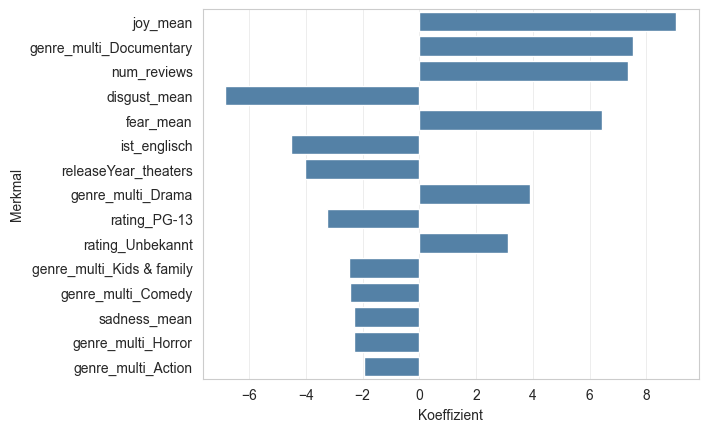

In [288]:
sns.set_style('whitegrid')
sns.barplot(data=koeffizienten_tomato.head(15), x='Koeffizient', y='Merkmal', color='steelblue')

In [303]:
for col in film_daten:
    print(col)

id
joy_mean
anger_mean
fear_mean
sadness_mean
surprise_mean
disgust_mean
neutral_mean
emotional_intensity_mean
emotional_intensity_std
num_reviews
title
audienceScore
tomatoMeter
releaseDateStreaming
runtimeMinutes
genre
originalLanguage
director
writer
ist_englisch
genre_einfach_Action
genre_einfach_Adventure
genre_einfach_Animation
genre_einfach_Biography
genre_einfach_Comedy
genre_einfach_Crime
genre_einfach_Documentary
genre_einfach_Drama
genre_einfach_Fantasy
genre_einfach_History
genre_einfach_Holiday
genre_einfach_Horror
genre_einfach_Kids & family
genre_einfach_Lgbtq+
genre_einfach_Music
genre_einfach_Musical
genre_einfach_Mystery & thriller
genre_einfach_Romance
genre_einfach_Sci-fi
genre_einfach_Stand-up
genre_einfach_Unbekannt
genre_einfach_War
genre_einfach_Western
meinungsverschiedenheit
rating
ratingContents
boxOffice
releaseDateTheaters
boxOffice_num
releaseYear_theaters
releaseMonth_theaters
ratingContents_anzahl
genre_multi_Action
genre_multi_Adventure
genre_multi_Anim